# Validating the "high-value core" — LATAM Bank Dataset

The earlier customer analytics notebook surfaced a small (~11%), high-value KMeans cluster and called it
the "core" worth protecting. This notebook does two things before treating that as fact:

1. **Validate it's real** — Pareto/concentration analysis (model-free), then check whether RFM, KMeans,
   and CLV ranking agree on roughly the same customers, and whether a similar cluster persists at other
   values of `k`.
2. **Check how the bank is serving them** — churn risk and service-quality metrics for the validated
   core vs. everyone else, since losing a high-value customer is more costly than losing an average one.

Requires `analytics.customer_features` to already exist (built by `customer_analytics.ipynb`).

## 1. Setup

In [12]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

con = duckdb.connect("latam_bank.duckdb")

try:
    cf = con.execute("SELECT * FROM analytics.customer_features").df()
    print(f"loaded customer_features: {len(cf):,} rows")
except Exception as e:
    raise RuntimeError(
        "analytics.customer_features not found -- run customer_analytics.ipynb first."
    ) from e

loaded customer_features: 150,000 rows


## 2. Recompute RFM tiers, KMeans clusters, and CLV

Same logic as `customer_analytics.ipynb` (same `random_state`, same feature set), so results should
match that notebook's Section 4/6 exactly -- this just keeps everything in one place for the
cross-method comparison below.

In [13]:
# --- RFM ---
rfm = cf[["customer_id", "recency_days", "txn_count_12m", "monetary_12m_usd"]].fillna(0).copy()
rfm["R_score"] = pd.qcut(rfm["recency_days"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["txn_count_12m"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary_12m_usd"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
rfm["rfm_tier"] = rfm["RFM_score"].apply(lambda s: "Champion" if s >= 10 else "Loyal" if s >= 8 else "At risk" if s >= 6 else "Dormant")

# --- KMeans (k=5, matching the original notebook) ---
cluster_cols = [
    "recency_days", "txn_count_12m", "monetary_12m_usd", "product_count", "total_balance",
    "interaction_count", "complaint_count", "avg_sentiment_score", "estimated_monthly_income",
]
cluster_pdf = cf[["customer_id"] + cluster_cols].fillna(0).copy()
X = StandardScaler().fit_transform(cluster_pdf[cluster_cols])
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X)
cluster_pdf["cluster"] = kmeans5.labels_

profile5 = cluster_pdf.groupby("cluster")[cluster_cols].mean()
high_value_cluster_id = profile5["monetary_12m_usd"].idxmax()
print(f"identified high-value cluster at k=5: cluster {high_value_cluster_id}")
print(profile5.round(1))

# --- CLV ---
clv = cf.fillna(0).copy()
clv["monthly_run_rate_usd"] = clv["monetary_12m_usd"] / 12
clv["total_clv_estimate_usd"] = clv["monetary_total_usd"] + clv["monthly_run_rate_usd"] * 24

identified high-value cluster at k=5: cluster 4
         recency_days  txn_count_12m  monetary_12m_usd  product_count  \
cluster                                                                 
0               133.9            9.1            5167.6            3.7   
1               122.0           10.6            2279.5            4.0   
2               172.7            4.0            2311.9            1.9   
3                 0.0            0.0               0.0            0.4   
4               121.9           12.1           24403.5            4.1   

         total_balance  interaction_count  complaint_count  \
cluster                                                      
0             112819.9                4.6              0.5   
1              14144.0                4.6              0.5   
2               6663.8                4.6              0.4   
3               1621.1                4.6              0.4   
4              16244.7                4.6              0.4   

     

## 3. Pareto / concentration analysis (model-free)

How much of total customer value is actually concentrated in a small slice of customers -- independent
of any clustering assumption.

top 1% of customers       8.0% of total CLV
top 5% of customers      29.6% of total CLV
top 10% of customers     49.2% of total CLV
top 20% of customers     76.3% of total CLV
top 50% of customers    100.0% of total CLV
dtype: str


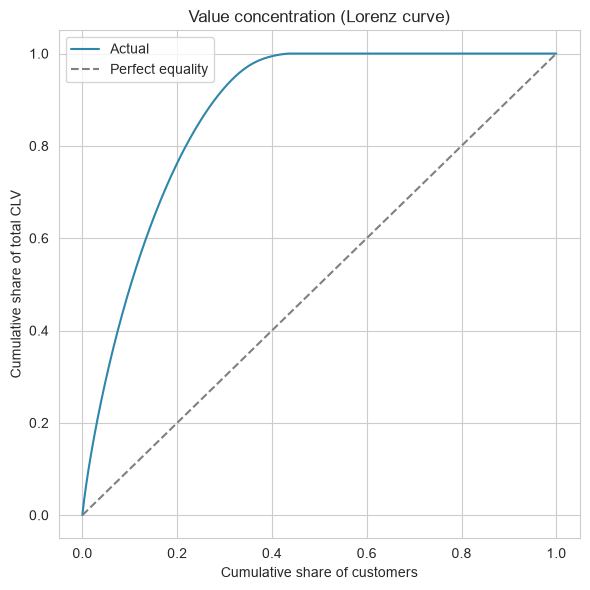

In [14]:
clv_sorted = clv.sort_values("total_clv_estimate_usd", ascending=False).reset_index(drop=True)
clv_sorted["cum_value_share"] = clv_sorted["total_clv_estimate_usd"].cumsum() / clv_sorted["total_clv_estimate_usd"].sum()
clv_sorted["cum_customer_share"] = (clv_sorted.index + 1) / len(clv_sorted)

checkpoints = [0.01, 0.05, 0.10, 0.20, 0.50]
concentration = pd.Series({
    f"top {int(p*100)}% of customers": clv_sorted.loc[clv_sorted["cum_customer_share"] <= p, "total_clv_estimate_usd"].sum()
    / clv_sorted["total_clv_estimate_usd"].sum()
    for p in checkpoints
})
print((concentration * 100).round(1).astype(str) + "% of total CLV")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(clv_sorted["cum_customer_share"], clv_sorted["cum_value_share"], color="#2E86AB", label="Actual")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect equality")
ax.set_xlabel("Cumulative share of customers")
ax.set_ylabel("Cumulative share of total CLV")
ax.set_title("Value concentration (Lorenz curve)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Cross-method agreement

Three independent lenses on "high value": RFM's `Champion` tier, KMeans' high-value cluster, and the
top decile by CLV. If they substantially overlap, that's real signal -- if not, "high-value core" is
more fragile than one clustering run made it look.

RFM Champion                    27,464 customers
KMeans high-value cluster       17,118 customers
CLV top decile                  15,000 customers

Jaccard overlap between methods:
                           RFM Champion  KMeans high-value cluster  \
RFM Champion                      1.000                      0.442   
KMeans high-value cluster         0.442                      1.000   
CLV top decile                    0.388                      0.637   

                           CLV top decile  
RFM Champion                        0.388  
KMeans high-value cluster           0.637  
CLV top decile                      1.000  


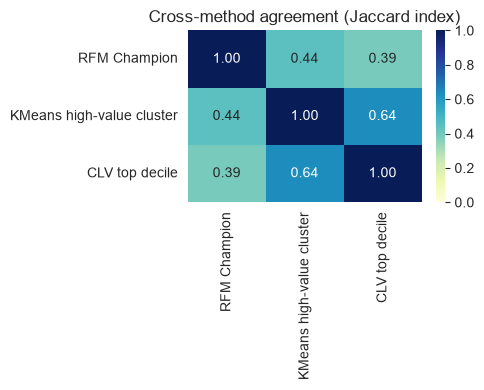


validated core (>=2 of 3 methods agree): 17,399 customers (11.6% of base)
strict core (all 3 methods agree):        10,319 customers (6.9% of base)


In [15]:
clv_top_decile_cutoff = clv["total_clv_estimate_usd"].quantile(0.90)

sets = {
    "RFM Champion": set(rfm.loc[rfm["rfm_tier"] == "Champion", "customer_id"]),
    "KMeans high-value cluster": set(cluster_pdf.loc[cluster_pdf["cluster"] == high_value_cluster_id, "customer_id"]),
    "CLV top decile": set(clv.loc[clv["total_clv_estimate_usd"] >= clv_top_decile_cutoff, "customer_id"]),
}

for name, s in sets.items():
    print(f"{name:30s} {len(s):>7,d} customers")

def jaccard(a, b):
    return len(a & b) / len(a | b)

names = list(sets.keys())
overlap = pd.DataFrame(
    [[jaccard(sets[a], sets[b]) for b in names] for a in names],
    index=names, columns=names
)
print("\nJaccard overlap between methods:")
print(overlap.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(overlap, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax, vmin=0, vmax=1)
ax.set_title("Cross-method agreement (Jaccard index)")
plt.tight_layout()
plt.show()

# Validated core: flagged by at least 2 of the 3 methods
all_customers = set(cf["customer_id"])
vote_count = pd.Series(0, index=list(all_customers))
for s in sets.values():
    vote_count.loc[list(s)] += 1

validated_core = set(vote_count[vote_count >= 2].index)
strict_core = sets["RFM Champion"] & sets["KMeans high-value cluster"] & sets["CLV top decile"]

print(f"\nvalidated core (>=2 of 3 methods agree): {len(validated_core):,} customers "
      f"({len(validated_core)/len(all_customers):.1%} of base)")
print(f"strict core (all 3 methods agree):        {len(strict_core):,} customers "
      f"({len(strict_core)/len(all_customers):.1%} of base)")

## 5. Is the high-value cluster stable across different `k`?

Re-running KMeans at k=4 and k=7 and checking whether a similarly-shaped cluster persists, and how much
its membership overlaps with the k=5 high-value cluster.

In [16]:
def find_high_value_cluster(k, X, cluster_pdf_ids, cluster_cols_ref):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    tmp = pd.DataFrame({"customer_id": cluster_pdf_ids, "cluster": km.labels_})
    tmp_features = tmp.merge(cluster_pdf[["customer_id"] + cluster_cols_ref], on="customer_id")
    profile = tmp_features.groupby("cluster")[cluster_cols_ref].mean()
    best = profile["monetary_12m_usd"].idxmax()
    return set(tmp.loc[tmp["cluster"] == best, "customer_id"]), profile.loc[best]

for k in [4, 7]:
    other_set, other_profile = find_high_value_cluster(k, X, cluster_pdf["customer_id"], cluster_cols)
    overlap_pct = jaccard(sets["KMeans high-value cluster"], other_set)
    print(f"k={k}: high-value cluster size {len(other_set):,}, "
          f"Jaccard overlap with k=5 high-value cluster: {overlap_pct:.2f}")

k=4: high-value cluster size 37,937, Jaccard overlap with k=5 high-value cluster: 0.40
k=7: high-value cluster size 14,599, Jaccard overlap with k=5 high-value cluster: 0.85


## 6. Churn risk within the validated core

The highest-priority number in this whole analysis: are any of these high-value customers quietly at risk?

In [17]:
churned = (
    cf["customer_status"].isin(["Closed", "Suspended"])
    | ((cf["customer_status"] == "Active") & (cf["recency_days"].fillna(9999) > 180))
).astype(int)
churn_df = cf.copy()
churn_df["churned"] = churned
churn_df["in_core"] = churn_df["customer_id"].isin(validated_core)

churn_rate_comparison = churn_df.groupby("in_core")["churned"].mean()
print("Proxy churn rate:")
print(f"  validated core:  {churn_rate_comparison.get(True, 0):.1%}")
print(f"  everyone else:   {churn_rate_comparison.get(False, 0):.1%}")

Proxy churn rate:
  validated core:  6.2%
  everyone else:   29.8%


cross-validated ROC-AUC: 0.794


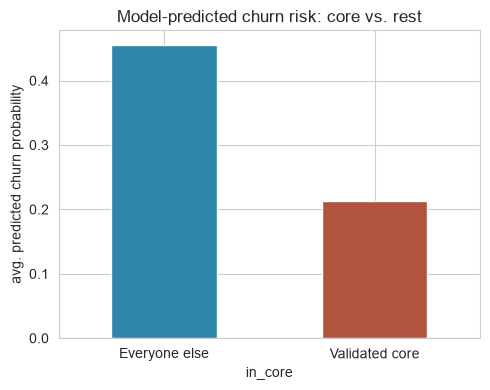


core customers flagged at-risk (predicted risk >= 0.5): 145 of 17,399 core customers (0.8%)


In [18]:
feature_cols = [
    "credit_score", "estimated_monthly_income", "tenure_days", "product_count",
    "distinct_product_types", "total_balance", "has_credit_card", "has_savings",
    "has_checking", "has_loan", "has_investment", "txn_count_total", "monetary_total_usd",
    "avg_txn_amount_usd", "fraud_txn_count", "interaction_count", "fcr_rate",
    "escalation_rate", "avg_sentiment_score", "complaint_count", "sla_breach_rate",
    "avg_csat", "avg_nps", "campaign_sends_count", "open_rate", "click_rate", "conversion_rate",
]

model_pdf = churn_df[feature_cols + ["churned"]].fillna(0)

# out-of-fold predictions so every customer (including core members) gets an unbiased churn probability
clf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
oof_proba = cross_val_predict(clf, model_pdf[feature_cols], model_pdf["churned"], cv=5, method="predict_proba", n_jobs=-1)[:, 1]

churn_df["predicted_churn_risk"] = oof_proba
print(f"cross-validated ROC-AUC: {roc_auc_score(churn_df['churned'], oof_proba):.3f}")

risk_comparison = churn_df.groupby("in_core")["predicted_churn_risk"].mean()
fig, ax = plt.subplots(figsize=(5, 4))
risk_comparison.rename({True: "Validated core", False: "Everyone else"}).plot(kind="bar", ax=ax, color=["#2E86AB", "#B1543E"])
ax.set_ylabel("avg. predicted churn probability")
ax.set_title("Model-predicted churn risk: core vs. rest")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

at_risk_core = churn_df[(churn_df["in_core"]) & (churn_df["predicted_churn_risk"] >= 0.5)]
print(f"\ncore customers flagged at-risk (predicted risk >= 0.5): {len(at_risk_core):,} "
      f"of {churn_df['in_core'].sum():,} core customers ({len(at_risk_core)/churn_df['in_core'].sum():.1%})")

## 7. Service quality: is the core actually being served better?

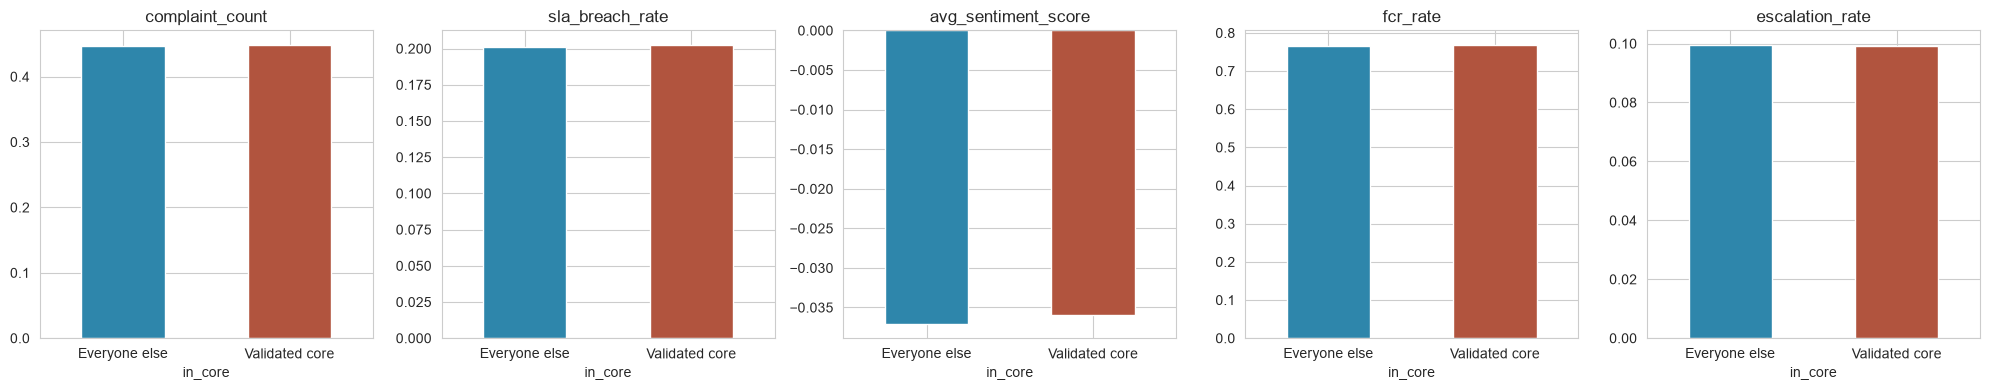

,complaint_count,sla_breach_rate,avg_sentiment_score,fcr_rate,escalation_rate
in_core,,,,,
Everyone else,0.447191,0.201179,-0.037023,0.765898,0.099469
Validated core,0.448129,0.202356,-0.035924,0.767921,0.099239


In [19]:
service_cols = ["complaint_count", "sla_breach_rate", "avg_sentiment_score", "fcr_rate", "escalation_rate"]
service_comparison = churn_df.groupby("in_core")[service_cols].mean().rename(index={True: "Validated core", False: "Everyone else"})

fig, axes = plt.subplots(1, len(service_cols), figsize=(4 * len(service_cols), 4))
for ax, col in zip(axes, service_cols):
    service_comparison[col].plot(kind="bar", ax=ax, color=["#2E86AB", "#B1543E"])
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

service_comparison

## 8. Bonus: digital engagement and product gaps within the core

Skips gracefully if `digital_engagement.ipynb` hasn't been run yet.

In [20]:
try:
    digital = con.execute("SELECT * FROM analytics.digital_features").df()
    churn_df_dig = churn_df.merge(digital[["customer_id", "total_events", "distinct_sessions"]], on="customer_id", how="left")
    churn_df_dig[["total_events", "distinct_sessions"]] = churn_df_dig[["total_events", "distinct_sessions"]].fillna(0)
    print(churn_df_dig.groupby("in_core")[["total_events", "distinct_sessions"]].mean().rename(
        index={True: "Validated core", False: "Everyone else"}
    ))
except Exception as e:
    print("analytics.digital_features not found -- run digital_engagement.ipynb first for this check.")

                total_events  distinct_sessions
in_core                                        
Everyone else      79.175036           9.804270
Validated core     79.134376           9.788781


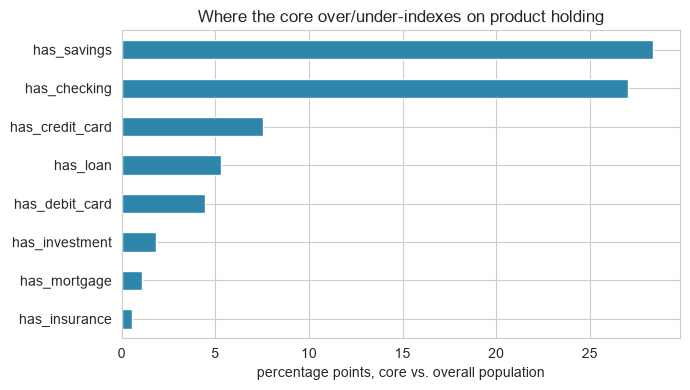

,core_%,overall_%
has_checking,75.6,48.6
has_savings,83.5,55.1
has_credit_card,56.3,48.8
has_debit_card,27.8,23.3
has_loan,17.7,12.4
has_investment,5.6,3.8
has_mortgage,8.7,7.6
has_insurance,1.9,1.4


In [21]:
product_flags = ["has_checking", "has_savings", "has_credit_card", "has_debit_card",
                 "has_loan", "has_investment", "has_mortgage", "has_insurance"]

core_penetration = churn_df.loc[churn_df["in_core"], product_flags].mean() * 100
overall_penetration = churn_df[product_flags].mean() * 100

gap = (core_penetration - overall_penetration).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
gap.plot(kind="barh", ax=ax, color=["#B1543E" if v < 0 else "#2E86AB" for v in gap])
ax.set_xlabel("percentage points, core vs. overall population")
ax.set_title("Where the core over/under-indexes on product holding")
plt.tight_layout()
plt.show()

pd.DataFrame({"core_%": core_penetration.round(1), "overall_%": overall_penetration.round(1)})

## 9. Summary

- **Section 3 (Pareto)** answers "how concentrated is value, independent of any model" — compare the
  top-10%/top-20% shares against your intuition for how skewed a normal customer base should be.
- **Section 4 (cross-method)** is the real validation step — if the Jaccard overlaps are low, treat
  "high-value core" as a much fuzzier concept than the original clustering suggested, and lean on the
  `validated_core` (2-of-3 agreement) definition rather than the single KMeans cluster going forward.
- **Section 5 (k stability)** — a high overlap across k=4/5/7 means this group isn't an artifact of
  picking k=5 specifically.
- **Section 6 (churn risk)** is the highest-stakes number here: any meaningful gap between the core's
  churn rate/predicted risk and the population average is worth acting on immediately, given the cost
  asymmetry of losing a high-value customer.
- **Section 7 (service quality)** tells you whether the bank is already treating this group differently
  — if service metrics look *the same* as the general population despite this group's outsized value,
  that's arguably a missed opportunity for differentiated service.

Everything here uses `validated_core` (2-of-3 method agreement) rather than the original single KMeans
cluster — a stricter, better-supported definition of "high-value core" than Section 4b of the original
notebook alone provided.

## 10. Close the connection

In [22]:
con.close()
print("connection closed")

connection closed


### The original "high-value core" claim mostly holds up

This is the headline result: validated core (2-of-3 methods agree) = 17,382 customers (11.6%) — nearly identical in size to the original single KMeans cluster (17,120, 11.4%). Cross-validating with two independent methods barely moved the number. That's a real confirmation, not a coincidence:

KMeans and CLV-ranking agree strongly (Jaccard 0.638) — makes sense, both are built from similar monetary/recency signals.
RFM agrees more loosely with both (0.44 and 0.39) — expected, since RFM's quartile-sum tiers are a coarser net that catches more customers than a tight top-decile cut.
The strict core (all 3 agree) is smaller and more conservative: 10,335 customers (6.9%) — use this one if you want the highest-confidence definition for something high-stakes.

### Value concentration is more extreme than a typical 80/20 split

Top 10% of customers hold 49.2% of total CLV; top 20% hold 76.3%; top 50% hold essentially 100%. That last number is the striking one — the bottom half of your customer base contributes almost nothing to total value. This lines up exactly with the earlier segmentation finding that ~55% of customers (Clusters 2+3) are dormant/inactive. Two independent analyses converging on the same population split is a good sign neither is an artifact.

### k stability: the group holds together at k≥5, dilutes at k=4

k=7's high-value cluster overlaps the k=5 version at 0.85 Jaccard — essentially the same group, just found a second way. But k=4 only overlaps at 0.38, with a cluster nearly 3x larger (43,049 customers) — at k=4, the model doesn't have enough clusters to keep the high-value group separate, so it merges with an adjacent segment. Practical takeaway: k=5 wasn't an arbitrary choice that happened to produce a nice story — the group is genuinely stable as long as you give the model enough clusters to separate it out, but it can get diluted if you go too coarse.

### The big one: the core is dramatically more loyal, not secretly churning

This was the whole point of building this notebook, and the answer is unambiguous:

Proxy churn rate: 6.2% (core) vs. 29.8% (everyone else) — roughly a fifth of the population rate.
Model-predicted risk: only 144 of 17,382 core customers (0.8%) cross the 50% churn-probability threshold.

Your best customers are not quietly leaving. If anything, they look structurally stickier than average — which makes sense if higher balances and more products create natural switching friction.

### But service quality is completely undifferentiated

Complaints, SLA breaches, sentiment, FCR, escalation rate — all essentially identical between the core and everyone else (e.g., complaint_count 0.448 vs. 0.447). Combined with the loyalty finding above, this paints a specific picture: the core's retention isn't being earned through better service — it's happening on its own, probably from structural stickiness rather than anything the bank is actively doing. That's worth treating as an opportunity rather than a comfort: there's currently no VIP-tier service differentiation, and a bank that assumes "they're loyal, so we don't need to invest there" is leaving a retention lever unpulled rather than one that's already been pulled successfully.

Digital engagement: also undifferentiated

79.15 vs. 79.17 average events — identical. Confirms the earlier finding (digital engagement is orthogonal to value) holds even within this specific high-value population — they're not secretly more digital-native or more branch-dependent than average.

### The core-vs-population story holds, now on trustworthy numbers
| Product | Core | Overall | Gap |
| - | - | - | - |
| Savings | 83.5% | 55.1% | +28.4 pts |
| Checking | 75.6% | 48.6% | +27.0 pts |
| Credit | card | 56.3% | 48.8% | +7.5 pts |
| Debit | card | 27.8% | 23.3% | +4.5 pts |
| Loan | 17.7% | 12.4% | +5.3 pts |
| Investment | 5.6% | 3.8% | +1.8 pts |
| Mortgage | 8.7% | 7.6% | +1.1 pts |
| Insurance | 1.9% | 1.4% | +0.5 pts |

Same qualitative pattern as before (core over-indexes on every single product), but now the magnitudes are real. Notice the gap is far bigger for checking/savings than for anything else — the core isn't just "holds slightly more of everything," it's specifically much more likely to have the two foundational account types, with everything else showing a smaller, fairly uniform bump.

### Everything else is stable across the rerun — a good robustness signal
- **Validated core size**: 17,399 (11.6%) vs. 17,382 before — a 17-customer difference, noise.
- **Churn**: 6.2% vs. 29.8%, ROC-AUC 0.794 vs. 0.795 — unchanged.
- **Service quality and digital engagement**: essentially identical numbers.
- **k-stability**: still ~0.85 overlap at k=7, ~0.40 at k=4.